# HW13 — токенизация, инференс BERT, fine-tuning (emotion)

Датасет `emotion` (6 классов). Для **готового инференса** используется облегчённая `bhadresh-savani/distilbert-base-uncased-emotion` (те же 6 меток, меньше веса и быстрее, чем полный BERT). Дообучение — с нуля `distilbert-base-uncased` + `Trainer`. После **Run All** обновляются `./artifacts/sample_predictions.csv` и `./artifacts/confusion_matrix.png`.


In [14]:
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    ROOT = Path.cwd()
ART = ROOT / "artifacts"
ART.mkdir(parents=True, exist_ok=True)


device: cpu


## Данные: sanity-check


In [15]:
ds = load_dataset("emotion")
label_names = ds["train"].features["label"].names
print("classes:", label_names)
print("train", len(ds["train"]), "val", len(ds["validation"]), "test", len(ds["test"]))
for i in range(3):
    print(ds["train"][i]["text"][:200], "->", label_names[ds["train"][i]["label"]])


classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
train 16000 val 2000 test 2000
i didnt feel humiliated -> sadness
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake -> sadness
im grabbing a minute to post i feel greedy wrong -> anger


## Токенизация (примеры)

Токены, `input_ids`, `attention_mask`, special tokens, padding/truncation.


In [16]:
tok_d = AutoTokenizer.from_pretrained("distilbert-base-uncased")
examples = ds["train"]["text"][:5]
for raw in examples:
    enc = tok_d(raw, truncation=True, max_length=32, padding="max_length")
    print("TEXT:", raw[:80], "...")
    print("tokens:", tok_d.convert_ids_to_tokens(enc["input_ids"]))
    print("input_ids (first 20):", enc["input_ids"][:20])
    print("attention_mask (first 20):", enc["attention_mask"][:20])
    print("cls/sep/pad:", tok_d.cls_token, tok_d.sep_token, tok_d.pad_token)
    print("---")


TEXT: i didnt feel humiliated ...
tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
input_ids (first 20): [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask (first 20): [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
cls/sep/pad: [CLS] [SEP] [PAD]
---
TEXT: i can go from feeling so hopeless to so damned hopeful just from being around so ...
tokens: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
input_ids (first 20): [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000

## Инференс готовой pretrained модели (та же задача emotion)


In [17]:
# Не используем pipeline: один батчевый forward. Для демо инференса — DistilBERT-emotion (~67M
# параметров), а не BERT-base (~110M): меньше объём скачивания и быстрее на CPU.
# Первый запуск всё равно качает файлы с Hugging Face; без HF_TOKEN лимиты могут сильно замедлять.
PRETRAINED_EMOTION = "bhadresh-savani/distilbert-base-uncased-emotion"

print("Токенизатор (скачивание при первом запуске)...", flush=True)
tok_pt = AutoTokenizer.from_pretrained(PRETRAINED_EMOTION)
print("Веса классификатора (основной объём)...", flush=True)
mdl_pt = AutoModelForSequenceClassification.from_pretrained(
    PRETRAINED_EMOTION,
    low_cpu_mem_usage=True,
)
mdl_pt.to(device)
mdl_pt.eval()

samples = [
    "I am thrilled about this!",
    "I feel lonely and empty.",
    "That movie made me terrified.",
    "I love spending time with you.",
    "This is confusing and weird.",
]

inputs = tok_pt(
    samples,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt",
)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.inference_mode():
    logits = mdl_pt(**inputs).logits
probs = torch.softmax(logits, dim=-1)
pred_ids = logits.argmax(dim=-1).cpu().tolist()
id2lbl = mdl_pt.config.id2label
nlab = mdl_pt.config.num_labels


def _lbl(i: int) -> str:
    return id2lbl[i] if i in id2lbl else id2lbl[str(i)]


for s, pid, row_p in zip(samples, pred_ids, probs):
    top = sorted(
        [(_lbl(i), float(row_p[i])) for i in range(nlab)],
        key=lambda x: -x[1],
    )[:2]
    print(s, "=>", top)

# Освободить память перед fine-tuning DistilBERT
del mdl_pt, logits, probs, inputs
import gc

gc.collect()


Токенизатор (скачивание при первом запуске)...
Веса классификатора (основной объём)...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6643.13it/s]


I am thrilled about this! => [('joy', 0.9988253712654114), ('love', 0.0004149848537053913)]
I feel lonely and empty. => [('sadness', 0.9989306330680847), ('fear', 0.0002597666752990335)]
That movie made me terrified. => [('fear', 0.9974074959754944), ('anger', 0.001015970017760992)]
I love spending time with you. => [('love', 0.9221423268318176), ('joy', 0.06777045130729675)]
This is confusing and weird. => [('fear', 0.9277569055557251), ('anger', 0.05501822754740715)]


1464

## Fine-tuning DistilBERT

Выбор лучшего чекпойнта по **validation f1_macro**; финальная оценка на **test** один раз в конце.

Для ускорения на CPU по умолчанию берётся подвыборка train; задайте `USE_FULL_TRAIN = True` для полного train.


In [18]:
MODEL_NAME = "distilbert-base-uncased"
USE_FULL_TRAIN = False

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)


td = ds.map(tokenize, batched=True).remove_columns(["text"]).rename_column("label", "labels")
td.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

train_raw = td["train"].shuffle(SEED)
train_ds = train_raw if USE_FULL_TRAIN else train_raw.select(range(min(4096, len(train_raw))))

id2label = {i: n for i, n in enumerate(label_names)}
label2id = {n: i for i, n in enumerate(label_names)}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(label_names), id2label=id2label, label2id=label2id
)
collator = DataCollatorWithPadding(tokenizer=tokenizer)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": float(accuracy_score(labels, preds)),
        "f1_macro": float(f1_score(labels, preds, average="macro")),
    }


args = TrainingArguments(
    output_dir=str(ART / "checkpoints"),
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2 if USE_FULL_TRAIN else 1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    seed=SEED,
    logging_steps=50,
    report_to="none",
)

try:
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=td["validation"],
        processing_class=tokenizer,
        data_collator=collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=td["validation"],
        tokenizer=tokenizer,
        data_collator=collator,
        compute_metrics=compute_metrics,
    )
trainer.train()
# В Jupyter отдельный evaluate() после train() иногда даёт RuntimeError в NotebookProgressCallback:
# "on_train_begin must be called before on_evaluate" (баг состояния колбэка в transformers).
# При eval_strategy="epoch" метрики validation уже есть в log_history после каждой эпохи.
_eval_rows = [h for h in trainer.state.log_history if "eval_loss" in h]
if _eval_rows:
    print("validation (последний eval при обучении):", _eval_rows[-1])
else:
    print("validation: eval_* в log_history не найдены")


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2972.74it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.376693,1.179848,0.580500,0.241546


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.93it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


validation (последний eval при обучении): {'eval_loss': 1.1798484325408936, 'eval_accuracy': 0.5805, 'eval_f1_macro': 0.2415458971721914, 'eval_runtime': 140.7504, 'eval_samples_per_second': 14.21, 'eval_steps_per_second': 0.448, 'epoch': 1.0, 'step': 128}


## Test (один раз), матрица ошибок, примеры предсказаний


test_accuracy 0.5945 test_f1_macro 0.24624186262454542


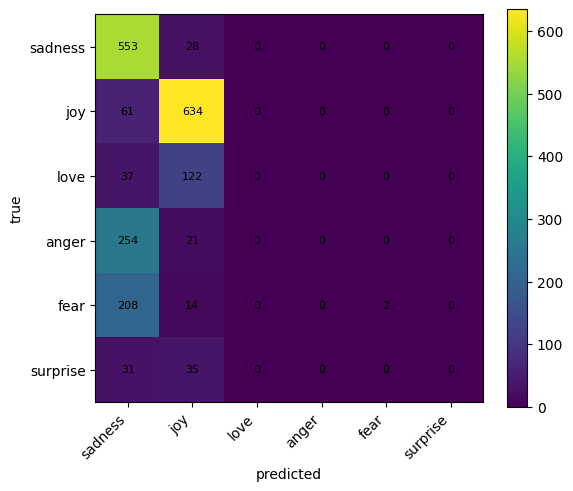

---
text: i cant walk into a shop anywhere where i do not feel uncomfortable
true: fear pred: sadness p: 0.41525161266326904
---
text: i felt anger when at the end of a telephone call
true: anger pred: sadness p: 0.4169429540634155
---
text: i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have been feeling for getting accepted into the masters program at the university of virginia
true: joy pred: sadness p: 0.46886542439460754
---
text: i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on vacation for the summer
true: anger pred: sadness p: 0.5290807485580444
---
text: i don t feel particularly agitated
true: fear pred: sadness p: 0.34523993730545044
---
text: i feel beautifully emotional knowing that these women of whom i knew just a handful were holding me and my baba on our journey
true: sadness pred: joy p: 0.56923854351

In [19]:
out = trainer.predict(td["test"])
pred = np.argmax(out.predictions, axis=-1)
y = out.label_ids
test_acc = float(accuracy_score(y, pred))
test_f1 = float(f1_score(y, pred, average="macro"))
print("test_accuracy", test_acc, "test_f1_macro", test_f1)

cm = confusion_matrix(y, pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_yticklabels(label_names)
ax.set_ylabel("true")
ax.set_xlabel("predicted")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(ART / "confusion_matrix.png", dpi=150)
plt.show()

probs = torch.softmax(torch.tensor(out.predictions), dim=-1).numpy().max(axis=1)
rows = []
for i in range(min(10, len(ds["test"]))):
    rows.append(
        {
            "text": ds["test"]["text"][i][:500],
            "true_label": label_names[y[i]],
            "pred_label": label_names[pred[i]],
            "confidence": float(probs[i]),
        }
    )
pd.DataFrame(rows).to_csv(ART / "sample_predictions.csv", index=False)

# 5–10 примеров для разбора ошибок
err_idx = [i for i in range(len(y)) if y[i] != pred[i]][:8]
for i in err_idx:
    print("---")
    print("text:", ds["test"]["text"][i][:300])
    print("true:", label_names[y[i]], "pred:", label_names[pred[i]], "p:", float(probs[i]))
